## Name:Shah Hetvi Ileshkumar

### project:3- Stock Price Prediction using Decision Tree Regressor 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df=pd.read_csv('stock_dataset.csv')

In [4]:
df

,Date,Open,High,Low,Close,Volume
0,2023-01-01,99.87,100.79,98.94,100.57,418693
1,2023-01-02,100.82,102.73,99.47,101.28,265575
2,2023-01-03,102.07,103.47,101.09,102.10,435938
3,2023-01-04,103.05,103.61,101.99,102.72,407257
4,2023-01-05,101.54,102.19,100.59,101.88,174069
...,...,...,...,...,...,...
245,2023-09-03,98.62,99.35,98.34,98.01,388179
246,2023-09-04,97.36,97.55,95.56,97.38,392764
247,2023-09-05,97.13,97.88,96.49,96.74,356553
248,2023-09-06,98.55,99.16,97.98,98.67,295113


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    250 non-null    str    
 1   Open    250 non-null    float64
 2   High    250 non-null    float64
 3   Low     250 non-null    float64
 4   Close   250 non-null    float64
 5   Volume  250 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 11.8 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,250.0,93.37748,4.581543,86.38,89.7850,92.180,97.0675,104.87
High,250.0,94.16560,4.577005,86.88,90.3575,93.110,97.6300,105.70
Low,250.0,92.60596,4.572818,85.04,88.9025,91.330,95.9950,104.17
Close,250.0,93.43332,4.627604,85.86,89.7325,92.185,96.8400,104.72
Volume,250.0,289356.30800,112272.745243,105901.00,197404.0000,291124.500,384264.7500,498872.00


In [7]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [8]:
df = df.drop(columns=['Date'])

In [9]:
df

,Open,High,Low,Close,Volume
0,99.87,100.79,98.94,100.57,418693
1,100.82,102.73,99.47,101.28,265575
2,102.07,103.47,101.09,102.10,435938
3,103.05,103.61,101.99,102.72,407257
4,101.54,102.19,100.59,101.88,174069
...,...,...,...,...,...
245,98.62,99.35,98.34,98.01,388179
246,97.36,97.55,95.56,97.38,392764
247,97.13,97.88,96.49,96.74,356553
248,98.55,99.16,97.98,98.67,295113


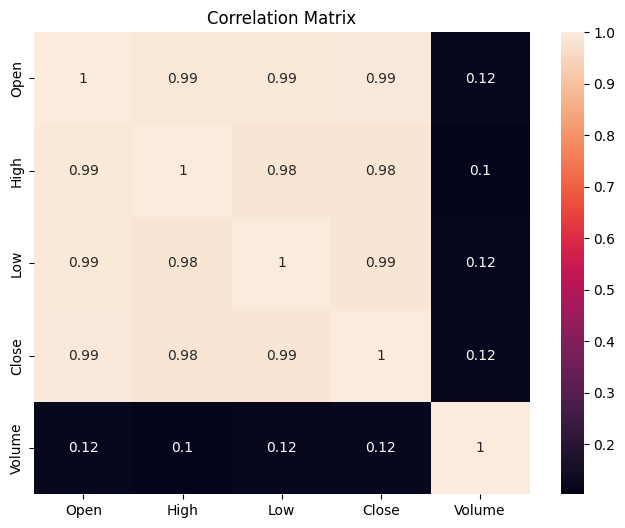

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [11]:
X = df.drop(columns='Close')
y = df['Close']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [14]:
y_pred = model.predict(X_test)

In [15]:
y_pred

array([ 86.79, 104.37,  89.74,  89.54,  86.48,  95.01,  92.86,  95.04,
       104.37,  85.86,  93.  , 100.74,  98.42,  99.69,  90.88, 100.9 ,
        92.2 ,  99.15,  93.01,  95.28,  96.81,  97.53,  89.69,  92.  ,
        91.74,  89.74,  90.97, 103.62,  93.66,  91.32,  93.01,  93.77,
        90.29, 101.08,  97.53,  87.29,  98.1 ,  92.17,  94.4 ,  89.68,
        90.77,  89.04,  89.63,  95.04, 100.74,  99.7 ,  88.09,  90.9 ,
        91.32,  92.  ])

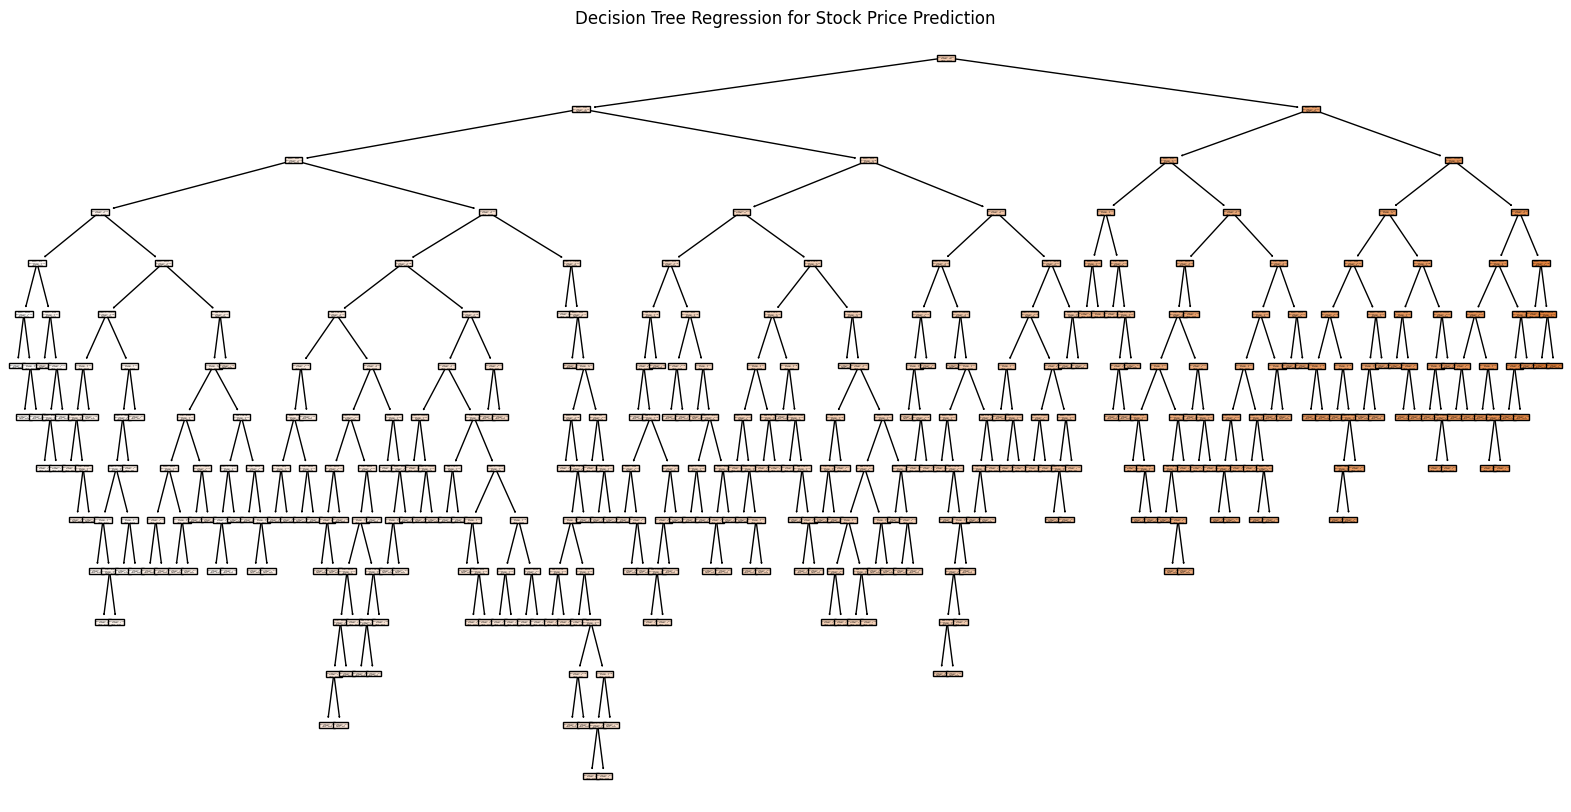

In [16]:
plt.figure(figsize=(20,10))
plot_tree(model,feature_names=X.columns,filled=True)
plt.title("Decision Tree Regression for Stock Price Prediction")
plt.show()

In [17]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.5570139999999977
R2 Score: 0.9758954131709772
